#Regression Analysis
---

## 1. Installing & Importing Libraries

In [13]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

print("All libraries imported successfully")

All libraries imported successfully


## 2. Loading & Inspecting the Data

In [14]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

print(f"Shape: {df.shape}")
df.head()

Shape: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Data Types:
total_bill    float64
tip           float64
sex            object
smoker         object
day            object
time           object
size            int64
dtype: object

Missing Values:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


In [4]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


## 3. Cleaning and restructuring the data
Encoding categorical columns (`sex`, `smoker`, `day`, `time`) into numeric values to use in the model.

In [5]:
df_model = df.copy()
le = LabelEncoder()

for col in ["sex", "smoker", "day", "time"]:
    df_model[col] = le.fit_transform(df_model[col])

df_model.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,2,0,2
1,10.34,1.66,1,0,2,0,3
2,21.01,3.50,1,0,2,0,3
3,23.68,3.31,1,0,2,0,2
4,24.59,3.61,0,0,2,0,4


## 4. Training / Test Spliting

In [15]:
FEATURES = ["total_bill", "size", "sex", "smoker", "day", "time"]
TARGET   = "tip"

X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

Training samples : 195
Test samples     : 49


## 5. Training the Model

In [16]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Model trained")

Model trained


## 6. Model Performance

In [17]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=" * 30)
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")
print("=" * 30)
print(f"\nInterpretation:")
print(f"  • Predictions are off by ~${rmse:.2f} on average")
print(f"  • The model explains ~{r2*100:.1f}% of the variance in tip amount")

  RMSE : 0.8336
  R²   : 0.4441

Interpretation:
  • Predictions are off by ~$0.83 on average
  • The model explains ~44.4% of the variance in tip amount


## 7. Feature Importance (Coefficients)

In [19]:
coef_df = pd.DataFrame({
    "Feature"    : FEATURES,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False).reset_index(drop=True)

print("Feature Coefficients (sorted by absolute value):")
coef_df

Feature Coefficients (sorted by absolute value):


,Feature,Coefficient
0,size,0.240303
1,smoker,-0.191744
2,total_bill,0.093965
3,time,0.061226
4,sex,0.032710
5,day,-0.006830


## 8. Visualisation — Bar Chart of Feature Coefficients

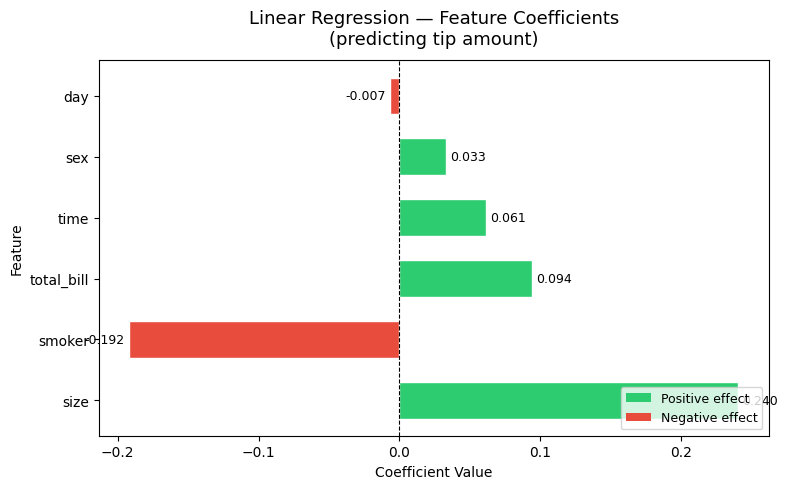

Chart saved as feature_coefficients.png ✅


In [20]:
colors = ["#2ecc71" if c >= 0 else "#e74c3c" for c in coef_df["Coefficient"]]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(
    coef_df["Feature"],
    coef_df["Coefficient"],
    color=colors,
    edgecolor="white",
    height=0.6
)

ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title(
    "Linear Regression — Feature Coefficients\n(predicting tip amount)",
    fontsize=13, pad=12
)
ax.set_xlabel("Coefficient Value")
ax.set_ylabel("Feature")

# Annotate bars with values
for bar, val in zip(bars, coef_df["Coefficient"]):
    x_pos = bar.get_width() + 0.003 if val >= 0 else bar.get_width() - 0.003
    ha = "left" if val >= 0 else "right"
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", ha=ha, fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#2ecc71", label="Positive effect"),
                   Patch(facecolor="#e74c3c", label="Negative effect")]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("feature_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as feature_coefficients.png ✅")

## 9. Downloading the Chart

In [21]:
from google.colab import files
files.download("feature_coefficients.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Summary


In [23]:
top_feature = coef_df.iloc[0]["Feature"]
top_coef    = coef_df.iloc[0]["Coefficient"]

print("=" * 40)
print(f"  RMSE                : {rmse:.4f}")
print(f"  R²                  : {r2:.4f}")
print(f"  Most influential    : {top_feature} (coef = {top_coef:.4f})")
print("=" * 40)
print(f"\n{top_feature} has the highest absolute coefficient, confirming")
print("that people tip as a proportion of what they spend.")

  RMSE                : 0.8336
  R²                  : 0.4441
  Most influential    : size (coef = 0.2403)

size has the highest absolute coefficient, confirming
that people tip as a proportion of what they spend.
